<h1> Market Basket Analysis and Customer segmentation</h1>

<h3>Problem Statement</h3>
<pre>Retailers want to understand customer purchasing behaviour in order to :
-recommend product
-design promotions
-improve sales

This Project analyzes transaction data to discover product associations and cutomer segments.</pre>



<h3> Objective</h3>
<pre>
-analyse customer purchase patterns
-discover products frequently bought together
-segment customer based on purchasing behaviour
-provide business insights</pre>

<h1>Importing Libaries


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h1>Loading dataset

In [22]:

df= pd.read_csv('dataset/OnlineRetail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,12/9/2011 12:50,4.15,12680.0,France


<h2>Data description</h2>
<p>This data is from UCI Machine Learning repository. This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.
It contains 8 columns and 541909 rows.</p>

<pre>
InvoiceNo -> transaction ID
StockCode -> product code
Description -> product nume
Quantity -> number of items
InvoiceDate -> purchase time
UnitPricde -> price of product
CustomerID -> unique customer identifier
Country -> cutomer country of purchase
</pre>


In [23]:
df.shape

(541909, 8)

In [24]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

<h2>Data Wrangling

checking missing values

In [25]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            2
InvoiceDate         0
UnitPrice           0
CustomerID     135081
Country             0
dtype: int64

<pre>remove cancelled transactions
cancelled invoices start with C</pre>

In [26]:
df= df[~df['InvoiceNo'].astype(str).str.contains('c')]

In [28]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,12/9/2011 12:50,4.15,12680.0,France


remove colums without customer ID


In [ ]:
df=df.dropna(subset=['CustomerID'])


In [35]:
df=df.dropna(subset=['Quantity'])

In [36]:
df.shape

(397921, 9)

Remove negative quantities

In [37]:
df= df[df['Quantity']>0]

Adding column (new Feature) Total price


In [38]:
df['TotalPrice']= df['Quantity'] * df['UnitPrice']

In [39]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


<h2>Exploratory Data Analysis (EDA)


Top selling products

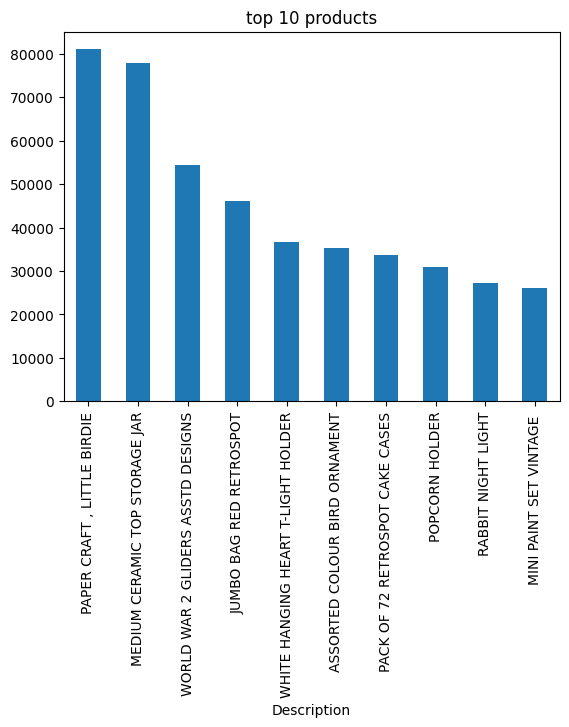

In [41]:
top_products= df.groupby('Description')['Quantity'].sum().sort_values(ascending= False).head(10)
top_products.plot(kind='bar')
plt.title('top 10 products')
plt.show()


Sales by Country

<Axes: xlabel='Country'>

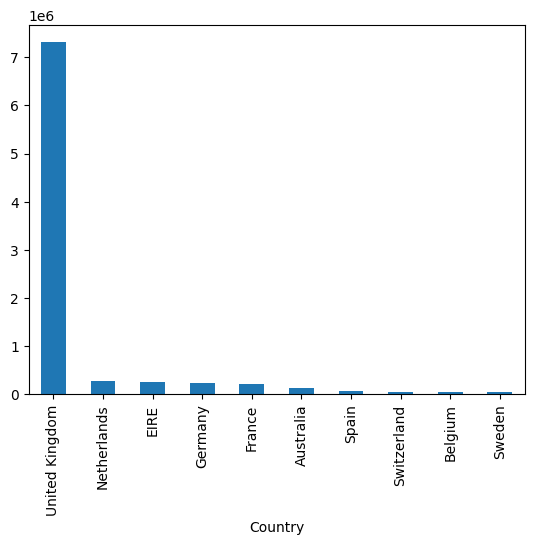

In [42]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_sales.head(10).plot(kind='bar')

Basket Size distribution

(0.0, 15000.0)

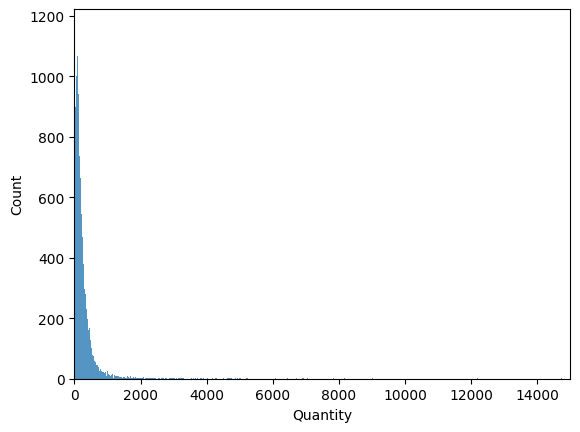

In [51]:
basket_size = df.groupby('InvoiceNo')['Quantity'].sum()
sns.histplot(basket_size)
plt.xlim(0, 15000)

In [ ]:
mean, mediam, mode